In [1]:
from ase.build import bulk

from atomdefectkit.basic_properties import BasicProperties
from atomdefectkit.screw import BCCScrewDislocation
from atomdefectkit.neb import BCCScrewDislocPeierlsBarrier

import numpy as np

from pyace import PyACECalculator

/Users/leizhang/Nextcloud/5_Coding/G_github/ASDbcc/.venv/lib/python3.11/site-packages/pyace/multispecies_basisextension.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Define the benchmark material and output location.
elem = 'W'
crystal_structure = 'bcc'
initial_a0 = 3.3  # Initial lattice-parameter guess in Angstrom.
working_dir = 'Test_W'

calc = PyACECalculator('/Users/leizhang/Nextcloud/1_Science_Postdoc_Projects/0_0_RUG_Screw_BCC/9_1_data_git/ACE2025_potential/W/output_potential.yaml')


In [3]:
# Initialize the basic-property workflow with a direct ACE calculator.
workflow = BasicProperties(calculator=calc, working_dir=working_dir)

# Build the conventional cubic BCC unit cell.
atoms = bulk(elem, crystal_structure, a=initial_a0, cubic=True)

# Estimate the equilibrium lattice parameter from both relaxation and EOS fitting.
a0_relax = workflow.calculate_equilibrium_a0_relax(atoms.copy(), fmax=0.001)
volumes, energies, a0_fit = workflow.calculate_equilibrium_a0_birch_murnaghan(atoms.copy(), vol_range=np.linspace(0.95, 1.05, 40))

# Sanity-check that the two lattice-parameter estimates agree.
if abs(a0_relax - a0_fit) > 1e-4:
    print('Lattice constant difference is', abs(a0_relax - a0_fit))
    print('Check the approach for getting lattice constant!')

# Update the bulk cell before computing defect and surface properties.
atoms.set_cell([a0_fit] * 3, scale_atoms=True)

Lattice constant difference is 0.02227895635325794
Check the approach for getting lattice constant!


In [4]:
from atomdefectkit.traction_separation import TractionSeparationWorkflow


In [5]:
workflow = TractionSeparationWorkflow(
    atoms=atoms,
    calculator=calc,
    repeat=(3, 3, 16),
    working_dir="ts_pure",
    optimizer="FIRE",
)

In [6]:
results = workflow.run_pure_separation(
    vacuum_values=np.linspace(0.0, 4.0, 40),
    write_xyz=True,
)

In [7]:
print(results["sigma_max_GPa"])
print(results["surface_energy_J_m2"])

51.45705518180477
4.168644354018771


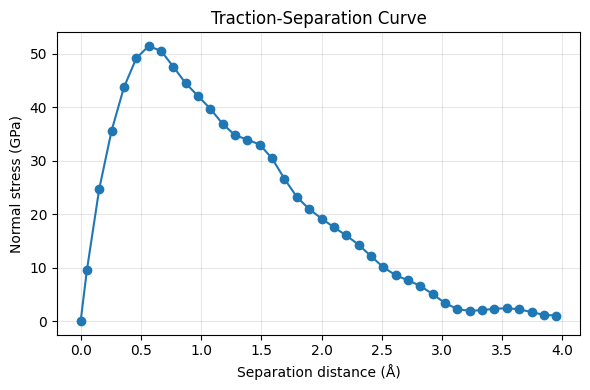

In [8]:
fig, ax = workflow.plot_pure_separation(results)